In [ ]:
# استيراد دالة رفع الملفات من مكتبة google.colab
from google.colab import files

# فتح نافذة لرفع ملفات من الجهاز المحلي إلى بيئة Google Colab
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"faresahmed00","key":"83b4a8d0d2d53063e6d9f8189032e898"}'}

In [ ]:
# إنشاء مجلد .kaggle داخل المسار الرئيسي للمستخدم (لو مش موجود)
!mkdir -p ~/.kaggle

# نسخ ملف kaggle.json (اللي فيه بيانات API Key) إلى المجلد .kaggle
!cp kaggle.json ~/.kaggle/

# تغيير صلاحيات الملف علشان يكون آمن: فقط المستخدم يقدر يقرأه ويكتبه
!chmod 600 ~/.kaggle/kaggle.json

#بتعمل مجلد .kaggle، وتنقل فيه ملف kaggle.json، وبعدين بتضبط صلاحيات الملف علشان يبقى آمن.



In [ ]:
# تحميل مجموعة بيانات "garbage-classification-v2" من Kaggle باستخدام الأمر kaggle datasets download
!kaggle datasets download -d sumn2u/garbage-classification-v2
#بتنزل مجموعة بيانات (Dataset) اسمها garbage-classification-v2 من حساب sumn2u على Kaggle.



Dataset URL: https://www.kaggle.com/datasets/sumn2u/garbage-classification-v2
License(s): MIT
 99% 733M/744M [00:02<00:00, 269MB/s]
100% 744M/744M [00:02<00:00, 363MB/s]


In [ ]:
# فك ضغط ملف البيانات "garbage-classification-v2.zip" داخل مجلد اسمه "garbage_dataset"
!unzip garbage-classification-v2.zip -d garbage_dataset


Streaming output truncated to the last 5000 lines.
  inflating: garbage_dataset/garbage-dataset/paper/paper_847.jpg  
  inflating: garbage_dataset/garbage-dataset/paper/paper_848.jpg  
  inflating: garbage_dataset/garbage-dataset/paper/paper_849.jpg  
  inflating: garbage_dataset/garbage-dataset/paper/paper_851.jpg  
  inflating: garbage_dataset/garbage-dataset/paper/paper_852.jpg  
  inflating: garbage_dataset/garbage-dataset/paper/paper_853.jpg  
  inflating: garbage_dataset/garbage-dataset/paper/paper_855.jpg  
  inflating: garbage_dataset/garbage-dataset/paper/paper_856.jpg  
  inflating: garbage_dataset/garbage-dataset/paper/paper_857.jpg  
  inflating: garbage_dataset/garbage-dataset/paper/paper_859.jpg  
  inflating: garbage_dataset/garbage-dataset/paper/paper_861.jpg  
  inflating: garbage_dataset/garbage-dataset/paper/paper_863.jpg  
  inflating: garbage_dataset/garbage-dataset/paper/paper_865.jpg  
  inflating: garbage_dataset/garbage-dataset/paper/paper_868.jpg  
  inflating

In [ ]:
# استيراد مكتبة os للتعامل مع الملفات والمجلدات
import os

# عرض قائمة بأسماء الملفات والمجلدات الموجودة داخل مجلد البيانات
os.listdir('garbage_dataset/garbage-dataset')



['shoes',
 'glass',
 'trash',
 'metal',
 'battery',
 'clothes',
 'cardboard',
 'paper',
 'biological',
 'plastic']

In [ ]:
# استيراد أداة تجهيز الصور من Keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# إنشاء مولّد بيانات مع إعادة تحجيم الصور (normalize) وتقسيم 20% منها للتحقق (validation)
data = ImageDataGenerator(rescale=1./255, validation_split=0.2)

# إعداد مولد بيانات التدريب: بياخد 80% من الصور
train_generator = data.flow_from_directory(
    'garbage_dataset/garbage-dataset',  # المسار الرئيسي للصور (كل فئة في مجلد)
    target_size=(224, 224),             # إعادة تحجيم الصور لكل صورة إلى 224x224 بكسل
    batch_size=32,                      # عدد الصور في كل دفعة تدريبية
    class_mode='categorical',           # التصنيف متعدد الفئات (كل صورة تنتمي لفئة واحدة فقط)
    subset='training'                   # استخدم هذه الدفعة كبيانات تدريب
)

# إعداد مولد بيانات التحقق (validation): بياخد 20% من الصور
val_generator = data.flow_from_directory(
    'garbage_dataset/garbage-dataset',  # نفس مسار البيانات
    target_size=(224, 224),             # نفس حجم الصور
    batch_size=32,                      # نفس حجم الدُفعة
    class_mode='categorical',           # نفس نوع التصنيف
    subset='validation'                 # استخدم هذه الدفعة للتحقق
)
#الخلية دي بتحضّر بيانات الصور للتدريب (training) والاختبار (validation) باستخدام ImageDataGenerator من مكتبة Keras.



Found 15813 images belonging to 10 classes.
Found 3949 images belonging to 10 classes.


In [ ]:
# استيراد النموذج MobileNetV2 (نموذج مدرّب مسبقًا من Keras)
from tensorflow.keras.applications import MobileNetV2

# استيراد الأدوات لبناء نموذج مخصص فوق MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout

# استيراد الـ Optimizer (آدم)
from tensorflow.keras.optimizers import Adam

# تحميل MobileNetV2 بدون طبقة التصنيف العلوية (include_top=False)، ومدخل الصور بحجم 224x224x3، واستخدام أوزان ImageNet
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')

# تجميد أوزان النموذج الأساسي حتى لا يتم تحديثها أثناء التدريب
base_model.trainable = False

# الحصول على المخرجات من MobileNetV2
x = base_model.output

# طبقة Global Average Pooling لتقليل الأبعاد وتحويل المخرجات إلى شكل أبسط
x = GlobalAveragePooling2D()(x)

# طبقة Dropout لتقليل overfitting بنسبة 40%
x = Dropout(0.4)(x)

# طبقة Dense بعدد 128 وحدة و ReLU لتنشيط البيانات
x = Dense(128, activation='relu')(x)

# طبقة Dropout إضافية بنسبة 30%
x = Dropout(0.3)(x)

# الطبقة الأخيرة للتصنيف بعدد فئات يساوي عدد الفئات في بيانات التدريب، مع softmax للإخراج
output = Dense(train_generator.num_classes, activation='softmax')(x)

# إنشاء النموذج النهائي بوصل MobileNetV2 بالطبقات المخصصة
model = Model(inputs=base_model.input, outputs=output)

# تجميع النموذج باستخدام خوارزمية Adam، وخسارة التصنيف متعددة الفئات
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

#دي أهم خلية لحد دلوقتي — بتبني نموذج تصنيف صور باستخدام MobileNetV2 كـ نموذج أساسي (pretrained model)، وبتضيف عليه طبقات تصنيف مخصصة.

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# استيراد أدوات المراقبة أثناء التدريب
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# إعداد EarlyStopping لإيقاف التدريب إذا الـ val_loss ما اتحسّنش
early_stop = EarlyStopping(
    monitor='val_loss',         # بيراقب خسارة الـ validation
    patience=2,                 # يوقف لو مفيش تحسن في 2 epochs ورا بعض
    restore_best_weights=True  # يرجع لأفضل أوزان تم الوصول لها أثناء التدريب
)

# إعداد ModelCheckpoint لحفظ أفضل نسخة من النموذج تلقائيًا
checkpoint = ModelCheckpoint(
    filepath='best_model.keras',  # اسم الملف اللي هيحفظ فيه الموديل
    monitor='val_loss',           # بيراقب خسارة الـ validation
    save_best_only=True           # يحفظ فقط لو النموذج فعلاً اتحسّن
)

# تدريب النموذج باستخدام بيانات التدريب والتحقق + callbacks
history = model.fit(
    train_generator,               # بيانات التدريب
    validation_data=val_generator, # بيانات التحقق (validation)
    epochs=5,                      # عدد الـ epochs
    callbacks=[early_stop, checkpoint]  # استخدم EarlyStopping و ModelCheckpoint
)
#الخلية دي بتدرّب النموذج، وبتستخدم callbacks علشان تحافظ على أفضل نسخة من الموديل وتوقف التدريب بدري لو النموذج بدأ يـ"أوفر فيت".

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
495/495 ━━━━━━━━━━━━━━━━━━━━ 86s 150ms/step - accuracy: 0.7312 - loss: 0.8403 - val_accuracy: 0.9028 - val_loss: 0.2976
Epoch 2/5
495/495 ━━━━━━━━━━━━━━━━━━━━ 57s 115ms/step - accuracy: 0.8806 - loss: 0.3642 - val_accuracy: 0.9126 - val_loss: 0.2669
Epoch 3/5
495/495 ━━━━━━━━━━━━━━━━━━━━ 56s 112ms/step - accuracy: 0.8991 - loss: 0.2969 - val_accuracy: 0.9180 - val_loss: 0.2466
Epoch 4/5
495/495 ━━━━━━━━━━━━━━━━━━━━ 57s 115ms/step - accuracy: 0.9077 - loss: 0.2664 - val_accuracy: 0.9205 - val_loss: 0.2387
Epoch 5/5
495/495 ━━━━━━━━━━━━━━━━━━━━ 56s 114ms/step - accuracy: 0.9194 - loss: 0.2388 - val_accuracy: 0.9268 - val_loss: 0.2313


In [ ]:
import pickle #مكتبه في بايثون لحفظ البيانات

with open('history.pkl', 'wb') as f:
    pickle.dump(history.history, f)
open('history.pkl', 'wb')
#	فتح أو إنشاء ملف اسمه history.pkl في وضع الكتابة الثنائية (wb = write binary)
#as f	احفظ الملف المفتوح باسم f علشان نستخدمه في السطر اللي بعده
#with	سياق آمن: يضمن إغلاق الملف تلقائيًا بعد الحفظ



<_io.BufferedWriter name='history.pkl'>

In [ ]:
model.save('model.keras')
#الخلية دي بتقوم بحفظ النموذج المدرب في ملف علشان تقدر تستخدمه لاحقًا بدون الحاجة لإعادة التدريب.



In [ ]:
# تحميل النموذج المحفوظ من ملف "model.keras"
from tensorflow.keras.models import load_model
model = load_model('model.keras')

# تقييم النموذج على بيانات التحقق (validation) لحساب الخسارة والدقة
loss, acc = model.evaluate(val_generator)

# طباعة نسبة الدقة على بيانات التحقق
print("Accuracy:", acc)
#الخلية دي بتحمّل النموذج المحفوظ، وبتقيم أداءه على بيانات التحقق (validation)، وبتطبع الدقة (accuracy).



124/124 ━━━━━━━━━━━━━━━━━━━━ 17s 103ms/step - accuracy: 0.9194 - loss: 0.2499
Accuracy: 0.9268169403076172


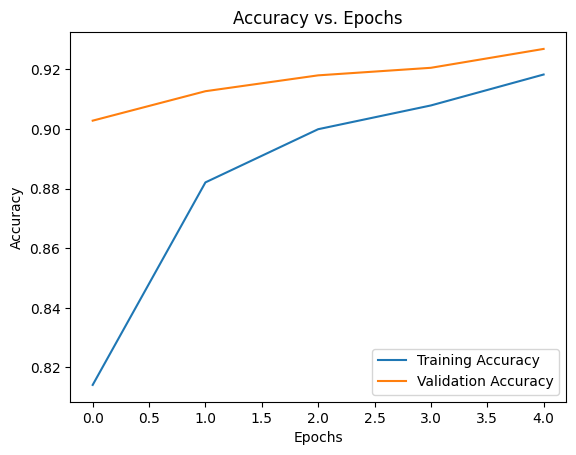

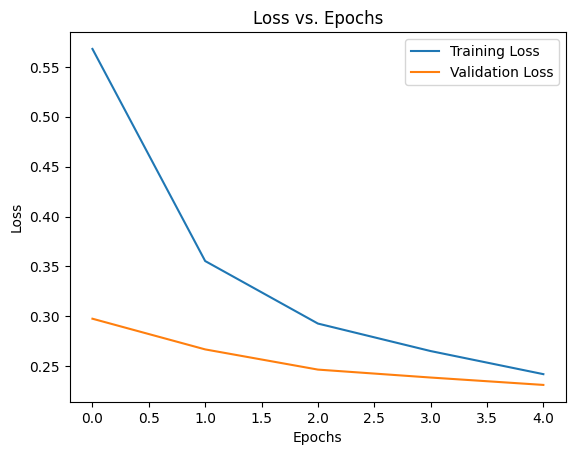

In [ ]:
# استيراد مكتبة matplotlib للرسم البياني
import matplotlib.pyplot as plt

# رسم منحنى الدقة خلال التدريب والتحقق
plt.plot(history.history['accuracy'], label='Training Accuracy')         # دقة التدريب
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')   # دقة التحقق
plt.title('Accuracy vs. Epochs')      # عنوان الرسم
plt.xlabel('Epochs')                  # المحور الأفقي = عدد الـ epochs
plt.ylabel('Accuracy')                # المحور الرأسي = الدقة
plt.legend()                          # عرض وسيلة الإيضاح
plt.show()                            # عرض الرسم

# رسم منحنى الخسارة خلال التدريب والتحقق
plt.plot(history.history['loss'], label='Training Loss')                 # خسارة التدريب
plt.plot(history.history['val_loss'], label='Validation Loss')           # خسارة التحقق
plt.title('Loss vs. Epochs')          # عنوان الرسم
plt.xlabel('Epochs')                  # المحور الأفقي = عدد الـ epochs
plt.ylabel('Loss')                    # المحور الرأسي = الخسارة
plt.legend()                          # عرض وسيلة الإيضاح
plt.show()                            # عرض الرسم
#الخلية دي بتستخدم مكتبة matplotlib لرسم منحنيات الدقة (accuracy) والخسارة (loss) خلال عملية التدريب — وده مفيد جدًا لفهم أداء النموذج بصريًا

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


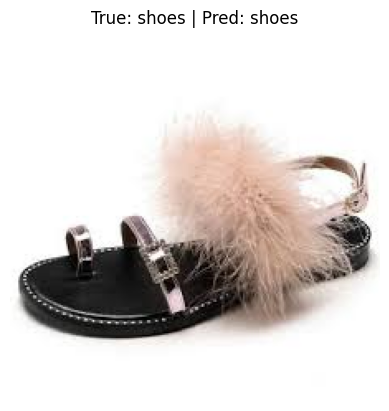

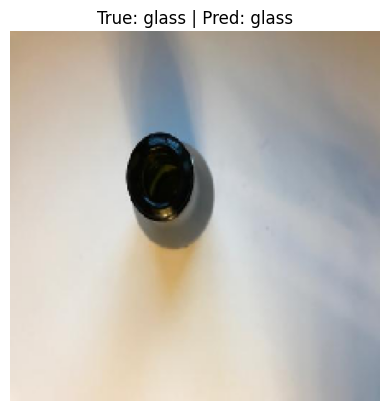

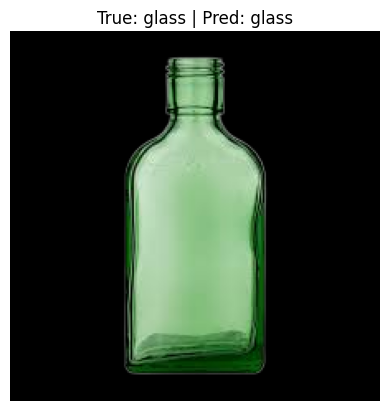

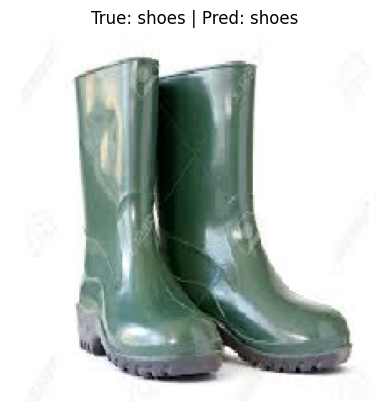

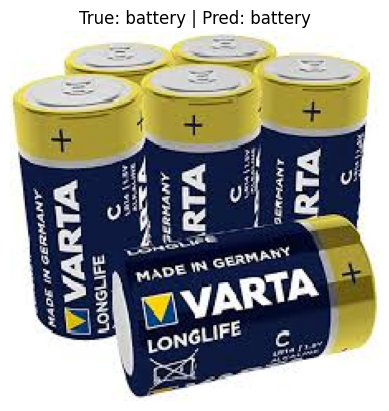

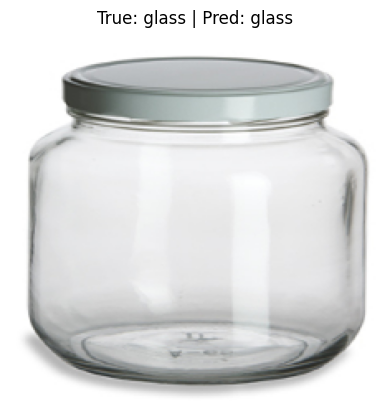

In [ ]:
# استيراد numpy للرؤية العددية و matplotlib لعرض الصور
import numpy as np
import matplotlib.pyplot as plt

# أخذ batch من الصور والتسميات من مولّد التحقق
images, labels = next(val_generator)

# تنفيذ التوقعات على الصور باستخدام النموذج
preds = model.predict(images)

# أخذ أعلى احتمالية من التوقعات لتحديد الفئة المتوقعة
pred_classes = np.argmax(preds, axis=1)

# استخراج الفئة الحقيقية من التسميات (one-hot → index)
true_classes = np.argmax(labels, axis=1)

# الحصول على أسماء الفئات من مولد البيانات
class_labels = list(val_generator.class_indices.keys())

# عرض أول 6 صور مع الفئة الحقيقية والمتوقعة
for i in range(6):
    plt.imshow(images[i])  # عرض الصورة
    plt.title(f"True: {class_labels[true_classes[i]]} | Pred: {class_labels[pred_classes[i]]}")  # عنوان فيه الفئة الحقيقية والمتوقعة
    plt.axis('off')  # إخفاء الإحداثيات
    plt.show()  # عرض الصورة
#الخلية دي بتنفذ توقعات (predictions) على شوية صور من بيانات التحقق، وبتعرض كل صورة مع التصنيف الحقيقي والتصنيف اللي النموذج تنبأ بيه

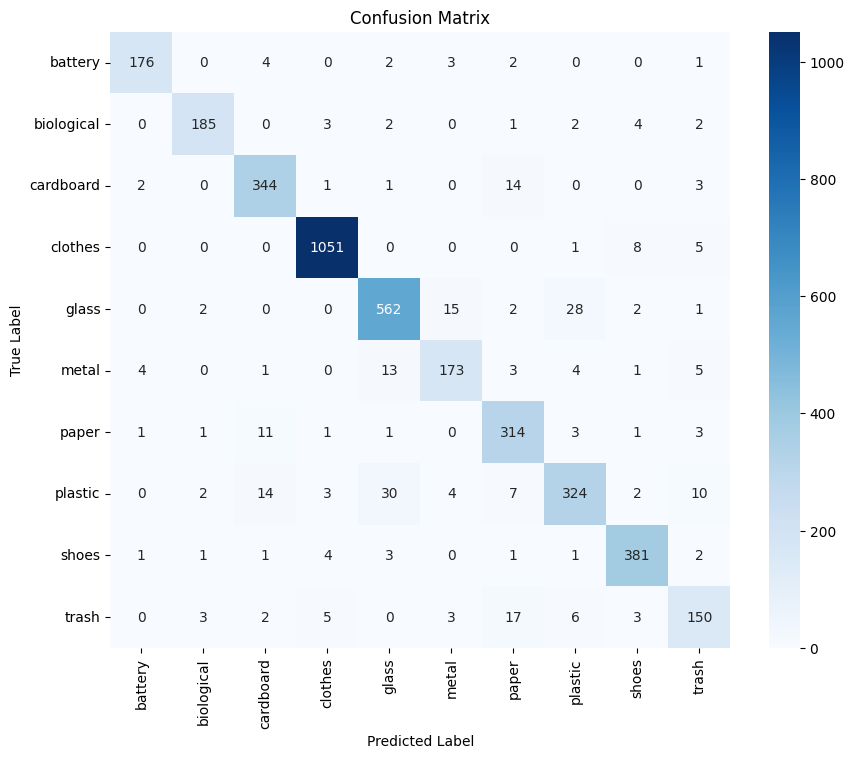

In [ ]:
# استيراد confusion_matrix من مكتبة scikit-learn و seaborn للرسم
from sklearn.metrics import confusion_matrix
import seaborn as sns

# إعادة ضبط مولد البيانات عشان يبدأ من الأول
val_generator.reset()

# مصفوفتين لتخزين كل التصنيفات الحقيقية والمتوقعة
all_true_classes = []
all_pred_classes = []

# عدد الـ steps (الدفعات) اللي هنمشيها لتغطية كل بيانات التحقق
steps = np.ceil(val_generator.samples / val_generator.batch_size)

# حلقة تمر على كل بيانات التحقق وتجمع التصنيفات
for _ in range(int(steps)):
    images, labels = next(val_generator)  # أخذ دفعة من الصور والليبلات
    preds = model.predict(images, verbose=0)  # التوقع
    pred_classes_batch = np.argmax(preds, axis=1)  # استخراج التصنيفات المتوقعة
    true_classes_batch = np.argmax(labels, axis=1)  # استخراج التصنيفات الحقيقية

    all_true_classes.extend(true_classes_batch)  # إضافة التصنيفات الحقيقية
    all_pred_classes.extend(pred_classes_batch)  # إضافة التصنيفات المتوقعة

# حساب مصفوفة الالتباس
cm = confusion_matrix(all_true_classes, all_pred_classes)

# أسماء الفئات (labels) من مولد البيانات
class_labels = list(val_generator.class_indices.keys())

# رسم مصفوفة الالتباس كـ heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')  # المحور X = التوقع
plt.ylabel('True Label')       # المحور Y = الحقيقة
plt.title('Confusion Matrix')  # العنوان
plt.show()
#الخلية دي بتعمل Confusion Matrix — ودي أداة مهمة جدًا علشان تشوف إزاي النموذج بيغلط أو بيخلط بين الفئات.



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━

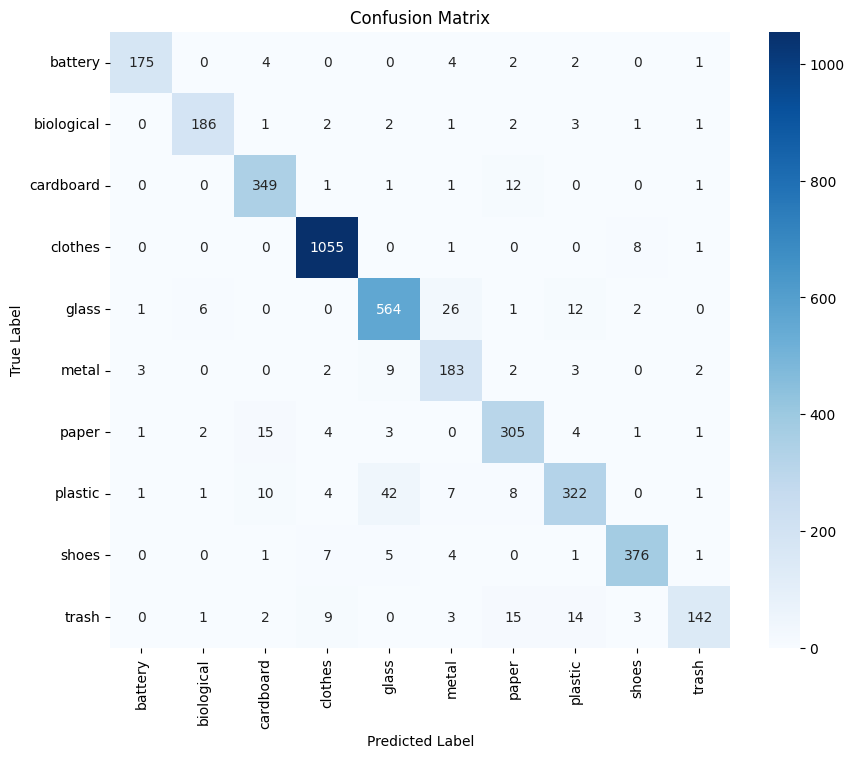

In [ ]:
# prompt: Make a graph of accuracy and loss and make a configuration matrix.

from sklearn.metrics import confusion_matrix
import seaborn as sns
val_generator.reset() # Reset generator to ensure we get data from the start
all_true_classes = []
all_pred_classes = []
num_batches = len(val_generator)
for i in range(num_batches):
    images, labels = next(val_generator)
    preds = model.predict(images)
    pred_classes = np.argmax(preds, axis=1)
    true_classes = np.argmax(labels, axis=1)
    all_true_classes.extend(true_classes)
    all_pred_classes.extend(pred_classes)

# Create confusion matrix
cm = confusion_matrix(all_true_classes, all_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# استيراد مكتبة TensorFlow
import tensorflow as tf

# تحميل الصور من المجلد، مع تغيير حجمها وتجميعها في دفعات
val_data = tf.keras.utils.image_dataset_from_directory(
    '/content/garbage_dataset/garbage-dataset',  # مسار المجلد اللي بيحتوي على الفئات
    image_size=(224, 224),                       # إعادة تحجيم الصور لكل صورة إلى 224x224
    batch_size=32                                # عدد الصور في كل دفعة
)

# استخراج أسماء الفئات من المجلدات
class_names = val_data.class_names
#الخلية دي بتستخدم image_dataset_from_directory لتحميل الصور كمجموعة بيانات (tf.data.Dataset) بدل ImageDataGenerator



Found 19762 files belonging to 10 classes.


Saving download (1).jpg to download (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
➡️  download (1).jpg  ==>  paper  (prob=0.91)


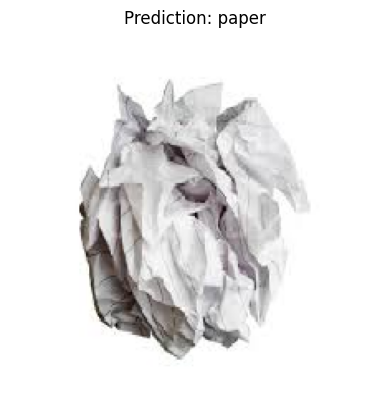

In [ ]:
import tensorflow as tf
from google.colab import files
import matplotlib.pyplot as plt
model = tf.keras.models.load_model('model.keras')
uploaded = files.upload()
class_names = val_data.class_names
for img_name in uploaded.keys():
    img = tf.keras.utils.load_img(img_name, target_size=(224, 224))
    img_array = tf.keras.utils.img_to_array(img) / 255.0
    img_array = tf.expand_dims(img_array, axis=0)
    preds = model.predict(img_array)
    pred_idx = tf.argmax(preds, axis=1).numpy()[0]
    print(f"➡️  {img_name}  ==>  {class_names[pred_idx]}  (prob={preds[0][pred_idx]:.2f})")
    plt.imshow(img)
    plt.title(f"Prediction: {class_names[pred_idx]}")
    plt.axis('off')
    plt.show()